参考：<br>
mathlogb @みぽさん：[第1種カニンガム鎖について調べてみた。どのくらい長くなるの？](https://mathlog.info/articles/1849)<br>
github @kaz Muzikさん： [CunninghamChain](https://github.com/kazkus/CunninghamChain)<br>
-以下自分の記録-<br>
ver0：[Cunningham Chain records.ipynb](https://gist.github.com/pppp314592/874213e856bdbf74abcae533f03a4651)<br>
ver1：[Cunningham Chain records -revenge-.ipynb](https://gist.github.com/pppp314592/e298afc5414d9803111b419ea08ebde7)<br>
ver2：[Cunningham Chain records -revenge- ver2.ipynb](https://gist.github.com/pppp314592/e11bee36ceadd345ae8ba23d8d3d5dea)

### 第１種カニンガム鎖 リベンジ ver.2

前回ver から基本アルゴリズムは変わらないが<br>
・篩のデータ管理を、BitVectorフラグ ⇛ 直接Int値の配列に変更 (巨大領域はこっちのが容量小さい)<br>
・↑変更により、処理が簡略化(filter!()処理化など、本体部はさっぱりした)<br>
・MySieve moduleを足切りCC値によるfunction化 (切替え可能に)<br>

随時足切り(可能になった)が大きいが、10倍程度早くなって取り回しやすくなった

以下、実際結果はいろいろ前後してます

In [2]:
versioninfo()

Julia Version 1.6.0
Commit f9720dc2eb (2021-03-24 12:55 UTC)
Platform Info:
  OS: Windows (x86_64-w64-mingw32)
  CPU: Intel(R) Core(TM) i5-3330 CPU @ 3.00GHz
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-11.0.1 (ORCJIT, ivybridge)
Environment:
  JULIA_EDITOR = "C:\Users\JUN\AppData\Local\Programs\Microsoft VS Code\Code.exe"
  JULIA_NUM_THREADS = 4


In [7]:
module MySieve  #篩リスト作り
import Primes:primes

wheel,mincc,mdllist,wheel_n=1,1,[2,[0]],[1]  #dummy

function createMySieve(cc=9)
    global mincc=max(cc,2)
    
    global wl = ifelse(cc ≤  9, [2,3,5,7,11,13,17]
               ,ifelse(cc ≤ 11, [2,3,5,7,11,13,17,19,23]
               ,ifelse(cc ≤ 13, [2,3,5,7,11,13,17,19,23,37,41]
                              , [2,3,5,7,11,13,17,19,23,37,41,43])))
    global wheel = prod(wl)

    mn(x,p,n=0) = (mod(x,p) ≠ 0 && n < mincc) ? mn(mod(2x+1,p),p,n+1) : n 　# x(mod p)でのcc途切れチェック
    modsieve(ps) = [ ( p , [i for i in 0:p-1 if mn(i,p) ≠ mincc] ) for p in ps ]
    maxmdl = ifelse(cc ≤ 12 , 1000
            ,ifelse(cc ≤ 13 , 3000
                            , 5000))
    global mdllist=modsieve(filter!(∉(wl),primes(maxmdl)))    #modulo篩リスト各(p,[0,1,..,p-1] {mod p})で篩ってよし

    (w_f,pprod)=([1],1)
    for (p,list) in modsieve(wl)                             #篩作り、p倍するときにmodulo篩にかけながら増やす
        (tmp,w_f)=(copy(w_f),Int[])
        for i in 0:p-1
            append!(w_f,filter(x -> mod(x,p) ∉ list , tmp.+i*pprod ))
        end
        pprod*=p
    end
    global wheel_n=w_f
    l=length(wheel_n)
    println("CC$(mincc)以上確認 wheel:$(wheel)(res.$(l)) 効率$(wheel÷l)倍")　　　#wheel中の篩の残りresidue
end
createMySieve(9)  #デフォCC9以上
end

CC9以上確認 wheel:510510(res.288) 効率1772倍


Main.MySieve

In [8]:
using Primes

@inline f(x)=Int128(2)x+1
@inline pn(x,n=0)= isprime(x) ? pn(f(x),n+1) : n

function mdlsieveCC(lo,hi
        ,wheel    =MySieve.wheel
        ,mincc    =MySieve.mincc
        ,mdllist  =MySieve.mdllist
        ,wheel_n  =MySieve.wheel_n
    )
    
    t=@timed Threads.@threads for k in (lo÷wheel):((hi-1)÷wheel)
        A=copy(wheel_n)
        for (p,list) in mdllist
            filter!(x-> mod(x+k*wheel,p) ∉ list ,A) #候補配列が小さくなっていく
        end
        println.("CC$(pn(x)):$(lpad(x,20))"  for x in A.+k*wheel if lo<x<hi && pn(x)≥mincc)
    end
    println("$(lo)($(length(digits(lo)))桁)～$(hi)($(length(digits(hi)))桁) CC$(mincc)以上の確認完了 : $(round(t.time,digits=2))sec")
end
mdlsieveCC(1,100) #JIT compile

1(1桁)～100(3桁) CC9以上の確認完了 : 0.24sec


### CC12以上の確認

In [16]:
MySieve.createMySieve(12)  #篩をCC12用に設定

mdlsieveCC(1,10^12-1)

CC12以上確認 wheel:338431883790(res.2192400) 効率154365倍
CC12:        554688278429
1(1桁)～999999999999(12桁) CC12以上の確認完了 : 0.3sec


### CC13以上の確認

In [4]:
MySieve.createMySieve(13) #篩をCC13用に設定

mdlsieveCC(10^12,10^13-1)

CC13以上確認 wheel:338431883790(res.1741824) 効率194297倍
1000000000000(13桁)～9999999999999(13桁) CC13以上の確認完了 : 1.72sec


In [18]:
mdlsieveCC(10^13,10^14-1)

10000000000000(14桁)～99999999999999(14桁) CC13以上の確認完了 : 14.59sec


In [19]:
mdlsieveCC(10^14,10^15-1)

100000000000000(15桁)～999999999999999(15桁) CC13以上の確認完了 : 148.91sec


In [5]:
N=10^15
for i in 1:4
    mdlsieveCC(i*N,(i+1)*N-1)
end

1000000000000000(16桁)～1999999999999999(16桁) CC13以上の確認完了 : 171.6sec
2000000000000000(16桁)～2999999999999999(16桁) CC13以上の確認完了 : 170.44sec
3000000000000000(16桁)～3999999999999999(16桁) CC13以上の確認完了 : 173.03sec
CC13:    4090932431513069
4000000000000000(16桁)～4999999999999999(16桁) CC13以上の確認完了 : 163.19sec


### CC14以上の確認

In [6]:
MySieve.createMySieve(14) #篩をCC14用に設定

CC14以上確認 wheel:14552571002970(res.38899440) 効率374107倍


In [7]:
N=10^15
for i in 5:9
    mdlsieveCC(i*N,(i+1)*N-1)
end

5000000000000000(16桁)～5999999999999999(16桁) CC14以上の確認完了 : 94.28sec
6000000000000000(16桁)～6999999999999999(16桁) CC14以上の確認完了 : 89.03sec
7000000000000000(16桁)～7999999999999999(16桁) CC14以上の確認完了 : 91.37sec
8000000000000000(16桁)～8999999999999999(16桁) CC14以上の確認完了 : 91.63sec
9000000000000000(16桁)～9999999999999999(16桁) CC14以上の確認完了 : 91.7sec


In [10]:
N=1*10^16
for i in 1:9
    mdlsieveCC(i*N,(i+1)*N-1)
end

10000000000000000(17桁)～19999999999999999(17桁) CC14以上の確認完了 : 861.1sec
20000000000000000(17桁)～29999999999999999(17桁) CC14以上の確認完了 : 841.89sec
30000000000000000(17桁)～39999999999999999(17桁) CC14以上の確認完了 : 836.95sec
40000000000000000(17桁)～49999999999999999(17桁) CC14以上の確認完了 : 838.92sec
50000000000000000(17桁)～59999999999999999(17桁) CC14以上の確認完了 : 854.99sec
60000000000000000(17桁)～69999999999999999(17桁) CC14以上の確認完了 : 842.1sec
70000000000000000(17桁)～79999999999999999(17桁) CC14以上の確認完了 : 838.05sec
80000000000000000(17桁)～89999999999999999(17桁) CC14以上の確認完了 : 836.97sec
CC14:   95405042230542329
90000000000000000(17桁)～99999999999999999(17桁) CC14以上の確認完了 : 832.89sec


### CC15以上の確認

In [11]:
MySieve.createMySieve(15) #篩をCC15用に設定

CC15以上確認 wheel:14552571002970(res.28664064) 効率507693倍


In [14]:
N=10^16
for i in 10:49
    mdlsieveCC(i*N,(i+1)*N-1)
end

100000000000000000(18桁)～109999999999999999(18桁) CC15以上の確認完了 : 569.31sec
110000000000000000(18桁)～119999999999999999(18桁) CC15以上の確認完了 : 567.51sec
120000000000000000(18桁)～129999999999999999(18桁) CC15以上の確認完了 : 564.37sec
130000000000000000(18桁)～139999999999999999(18桁) CC15以上の確認完了 : 563.35sec
140000000000000000(18桁)～149999999999999999(18桁) CC15以上の確認完了 : 637.73sec
150000000000000000(18桁)～159999999999999999(18桁) CC15以上の確認完了 : 585.92sec
160000000000000000(18桁)～169999999999999999(18桁) CC15以上の確認完了 : 608.82sec
170000000000000000(18桁)～179999999999999999(18桁) CC15以上の確認完了 : 569.37sec
180000000000000000(18桁)～189999999999999999(18桁) CC15以上の確認完了 : 569.33sec
190000000000000000(18桁)～199999999999999999(18桁) CC15以上の確認完了 : 563.59sec
200000000000000000(18桁)～209999999999999999(18桁) CC15以上の確認完了 : 561.18sec
210000000000000000(18桁)～219999999999999999(18桁) CC15以上の確認完了 : 560.99sec
220000000000000000(18桁)～229999999999999999(18桁) CC15以上の確認完了 : 562.14sec
230000000000000000(18桁)～239999999999999999(18桁) CC15以上の確認完了 : 56

ver.1では10^17の範囲に15hr必要だが、ver.2で1.5hrになった(CC14以下無視しているが)<br>
あと10^18以上では、いろいろInt64→Int128にする必要があり速度低下が見込まれる<br>
以下確認中(10^20になるまでたぶん何もない)

別PC(強)による確認結果

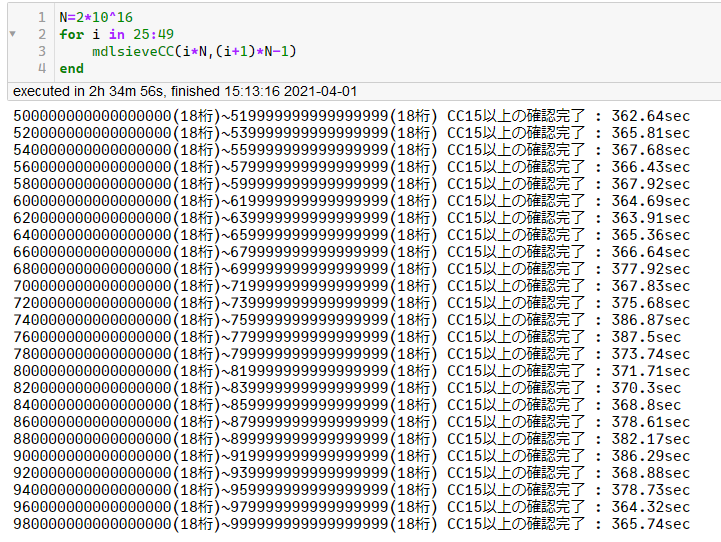

10^18まで(18桁) CC15以上なし

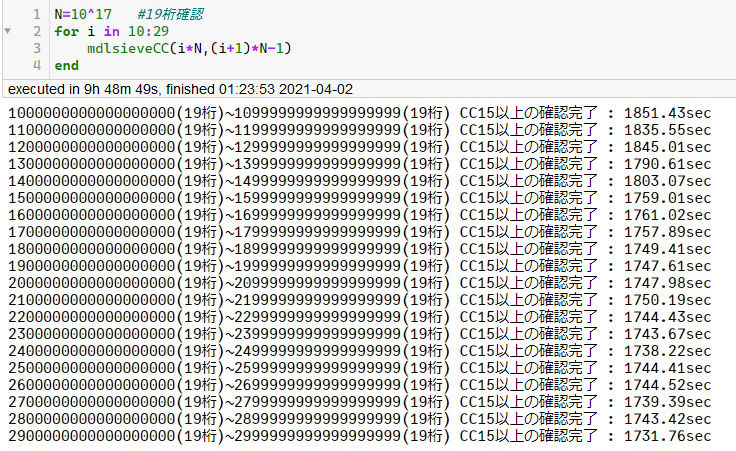

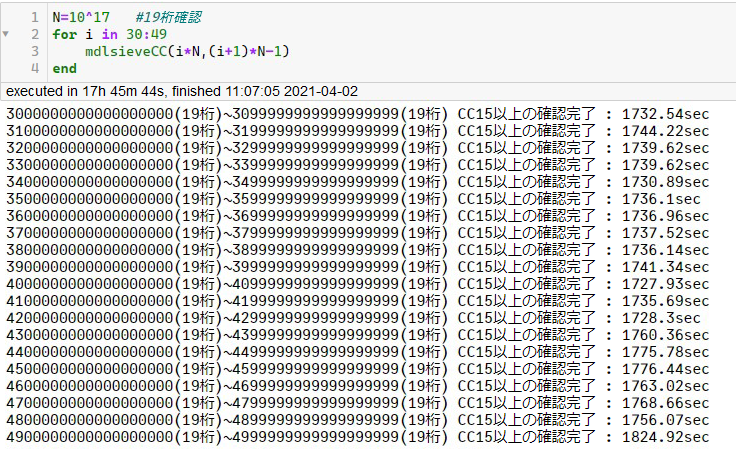

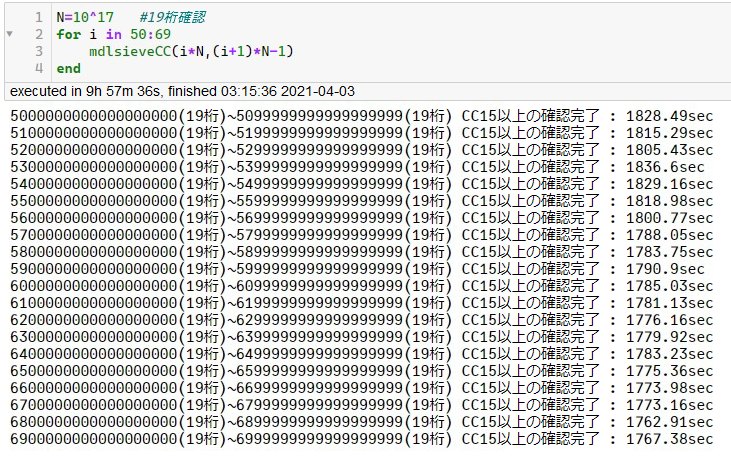

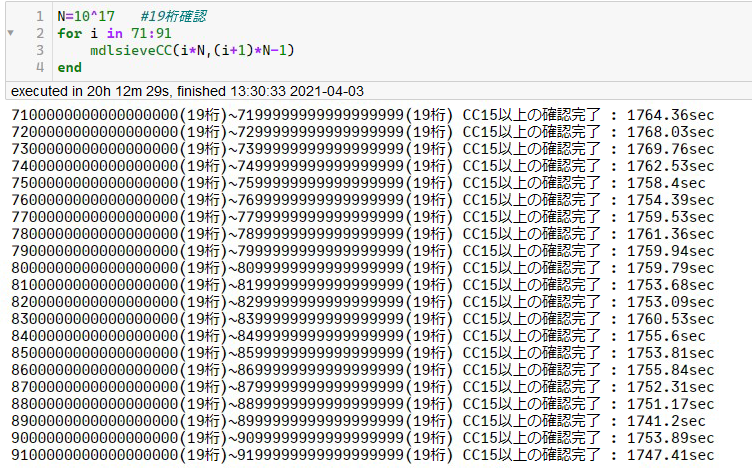

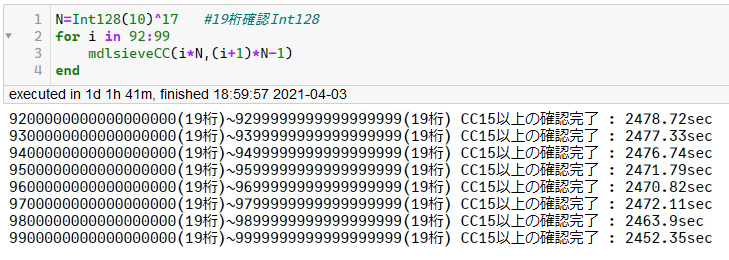

10^19まで(19桁) CC15以上なし

10^20(20桁)の確認は強PCでも1ヶ月程度回し続ける計算・・・